#### Import

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent

SRC_PATH = PROJECT_ROOT/ 'src'
if str(SRC_PATH) not in sys.path: 
    sys.path.append(str(SRC_PATH))

import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from config import (
    PA_TABLE_PARQUET,
    INTERTIES_HOUR_AHEAD_PARQUET,
    INTERTIE_CAPABILITY_PARQUET,
    GENERATION_PARQUET,
    OUTAGES_PARQUET,
    CALENDAR_FEATURES,
    LOAD_WEATHER_FEATURES,
    MARKET_FEATURES,
    RENEWABLE_WEATHER_FEATURES,
    RANDOM_SEED,
)

# Suppress warnings so the outputs in the notebooks stay cleaner. 
warnings.filterwarnings('ignore')
# This handles that annoying output compression where you get '...'
# instead of displaying all columns.
pd.set_option('display.max_columns', None)
# Changes the output width of the jupyter notebook. 
pd.set_option('display.width', 120)
np.random.seed(RANDOM_SEED)

pa_hourly = pd.read_parquet(PA_TABLE_PARQUET)
interties_hour_ahead = pd.read_parquet(INTERTIES_HOUR_AHEAD_PARQUET)
intertie_capability = pd.read_parquet(INTERTIE_CAPABILITY_PARQUET)
generation = pd.read_parquet(GENERATION_PARQUET)
outages = pd.read_parquet(OUTAGES_PARQUET)
calendar = pd.read_parquet(CALENDAR_FEATURES)
weather = pd.read_parquet(LOAD_WEATHER_FEATURES)
market = pd.read_parquet(MARKET_FEATURES)
renewables = pd.read_parquet(RENEWABLE_WEATHER_FEATURES)

#### Dataset Overview

In [2]:
summary = []

datasets = {
    'pa_hourly': pa_hourly,
    'interties': interties_hour_ahead,
    'intertie_capability': intertie_capability,
    'generation': generation,
    'outages': outages,
    'calendar': calendar,
    'weather': weather,
    'market': market,
    'renewables': renewables,
}

for name, df in datasets.items():
    summary.append({
        'Dataset': name,
        'Rows': len(df),
        'Columns': len(df.columns),
        'Start': df['timestamp_utc'].min(),
        'End': df['timestamp_utc'].max(),
        'Duplicate timestamps': df['timestamp_utc'].duplicated().sum(),
        'Missing values': int(df.isna().sum().sum()),
        'Memory (MB)': round(df.memory_usage(deep=True).sum() / 1e6, 2),
    })

summary = pd.DataFrame(summary)

summary

,Dataset,Rows,Columns,Start,End,Duplicate timestamps,Missing values,Memory (MB)
0,pa_hourly,100055,5,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,0,4.00
1,interties,136583,8,2010-01-01 07:00:00+00:00,2025-08-01 05:00:00+00:00,0,62786,8.74
2,intertie_capability,100033,9,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,0,7.20
3,generation,100055,61,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,985430,48.83
4,outages,100033,13,2015-01-01 07:00:00+00:00,2026-05-31 07:00:00+00:00,0,197686,10.40
5,calendar,100776,46,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,0,19.16
6,weather,87672,73,2015-01-01 00:00:00+00:00,2024-12-31 23:00:00+00:00,0,110326,45.68
7,market,100055,264,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0,739383,185.12
8,renewables,100776,51,2015-01-01 00:00:00+00:00,2026-06-30 23:00:00+00:00,0,44295,41.12


In [3]:
# Missing values - column specific.

for name, df in datasets.items():
    missing = df.isna().sum()

    missing = missing[missing > 0]

    print(f'\n{name}')

    if missing.empty: 
        print('No missing values.')
    else: 
        print(missing.sort_values(ascending = False))


pa_hourly
No missing values.

interties
export_mt                    31391
import_mt                    31391
hour_ahead_price_forecast        4
dtype: int64

intertie_capability
No missing values.

generation
gas_fired_steam_system_available     53352
gas_fired_steam_system_generation    53352
gas_fired_steam_maximum_capacity     53352
gas_fired_steam_system_capacity      53352
gas_fired_steam_total_generation     53352
storage_total_generation             51143
storage_system_capacity              51143
storage_system_available             51143
storage_maximum_capacity             51143
storage_system_generation            51143
dual_fuel_system_available           50135
dual_fuel_system_generation          50135
dual_fuel_total_generation           50135
dual_fuel_system_capacity            50135
dual_fuel_maximum_capacity           50135
solar_total_generation               25656
solar_system_available               25656
solar_system_capacity                25656
solar_system_ge

* Hour ahead price forecast only missing 4 values is essentailly complete. 
* Montana may have not been reporting intertie data for parts of the historical record. 
* Generation is a different case, you'd expect missing values as technologies phase-in and phase-out across time.
* Same applies to outages - technologies have to exist to experience outages. 
* Market features dataset inherets alot of missingness from generation. 
* Solar clear sky radiation is missing alot of values during nighttime. 

#### External Data Checks

In [4]:
print(interties_hour_ahead.loc[
    interties_hour_ahead['import_mt'].notna(),
    'timestamp_utc'
].min())

print(interties_hour_ahead.loc[
    interties_hour_ahead['export_mt'].notna(),
    'timestamp_utc'
].min())

2013-08-01 06:00:00+00:00
2013-08-01 06:00:00+00:00


In [5]:
cutoff = pd.Timestamp('2013-08-01 06:00:00+00:00', tz = 'UTC')

mt_missing = (
    interties_hour_ahead.loc[interties_hour_ahead['timestamp_utc'] > cutoff,
        ['import_mt', 'export_mt']].isna().sum()
)

print(mt_missing)

import_mt    0
export_mt    0
dtype: int64


Montana Intertie Data: 
* import_mt and export_mt are missing prior to August 2013. Investigation confirmed these missing values are expected: the Montana-Alberta Tie Line (MATL) entered service in 2013, and AESO public reporting of Montana intertie schedules and transfer capability began around the commissioning period. These missing values therefore represent the absence of an operational/reporting intertie rather than data quality issues. Missing values disappear after 2013-08-01 06:00:00+00:00 UTC. 

In [6]:
generation_coverage = []

for col in generation.columns:
    if col == 'timestamp_utc': 
        continue

    non_missing = generation.loc[generation[col].notna(), 'timestamp_utc']

    generation_coverage.append({
        'Column': col,
        'First non-missing': non_missing.min(),
        'Last non-missing': non_missing.max(),
        'Missing': generation[col].isna().sum(),
    })

generation_coverage = (
    pd.DataFrame(generation_coverage).sort_values('First non-missing')
)

generation_coverage

,Column,First non-missing,Last non-missing,Missing
0,coal_system_generation,2015-01-01 07:00:00+00:00,2024-07-01 05:00:00+00:00,16800
28,other_system_available,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
58,total_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
32,wind_system_available,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
33,coal_system_capacity,2015-01-01 07:00:00+00:00,2024-07-01 05:00:00+00:00,16800
34,cogeneration_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
35,combined_cycle_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
38,hydro_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
39,other_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0
40,simple_cycle_system_capacity,2015-01-01 07:00:00+00:00,2026-06-01 05:00:00+00:00,0


Generation Data: 
* Missingness in the generation dataset is highly structured by fuel category. Coal and dual-fuel fields terminate around Alberta’s final coal-to-gas conversions in July 2024, while solar and storage fields begin later as those categories entered AESO reporting. Gas-fired steam and the beginning of dual-fuel coverage likely reflect AESO classification or reporting changes rather than the physical introduction of those technologies. Because all metrics within each category share identical coverage boundaries, the missing values are treated as structurally unavailable rather than randomly missing.


# Notebook 1 - Understanding the Alberta Electricity Market

#### Understanding the Alberta Electricity Market 

Purpose:
This notebook introduces the Alberta electricity market and establishes the operational context for the analyses that follow.
Rather than developing predictive models, the objective is to understand how the system behaves:
* how electricity demand evolves over time
* how supply is provided
* how prices behave
* how generation technologies contribute
* how imports and outages influence operations
* how the market has changed over the study period
The observations developed here form the foundation for later notebooks on market regimes, scarcity, feature engineering, and forecasting.

#### Merge

In [7]:
# =============================================================================
# Merge canonical feature datasets and attach calendar features
# =============================================================================

merge_key = "timestamp_utc"

# Calendar is the canonical source for all timestamp-derived fields.
# It is placed first so its calendar columns are retained whenever an
# incoming dataset contains identical copies.
datasets = {
    "calendar": calendar,
    "market": market,
    "intertie_capability": intertie_capability,
    "generation": generation,
    "weather": weather,
    "renewables": renewables,
}

duplicate_columns_removed = []

# =============================================================================
# Validate merge keys before merging
# =============================================================================

for dataset_name, df in datasets.items():

    if merge_key not in df.columns:
        raise KeyError(
            f"{merge_key!r} is missing from dataset "
            f"{dataset_name!r}."
        )

    duplicate_timestamps = df[merge_key].duplicated().sum()

    if duplicate_timestamps:
        raise ValueError(
            f"Dataset {dataset_name!r} contains "
            f"{duplicate_timestamps:,} duplicate timestamps."
        )

# =============================================================================
# Start with canonical calendar table
# =============================================================================

first_name, first_df = next(iter(datasets.items()))

master = (
    first_df
    .sort_values(merge_key)
    .copy()
)

# =============================================================================
# Merge remaining datasets
# =============================================================================

for dataset_name, df in list(datasets.items())[1:]:

    incoming = (
        df
        .sort_values(merge_key)
        .copy()
    )

    # Find shared non-key column names.
    overlapping_columns = sorted(
        (set(master.columns) & set(incoming.columns))
        - {merge_key}
    )

    columns_to_drop = []

    for column in overlapping_columns:

        comparison = (
            master[[merge_key, column]]
            .merge(
                incoming[[merge_key, column]],
                on=merge_key,
                how="inner",
                suffixes=("_master", "_incoming"),
                validate="one_to_one",
            )
        )

        master_col = f"{column}_master"
        incoming_col = f"{column}_incoming"

        values_match = (
            comparison[master_col].eq(
                comparison[incoming_col]
            )
            | (
                comparison[master_col].isna()
                & comparison[incoming_col].isna()
            )
        )

        if values_match.all():

            # Retain the version already present in master.
            # For calendar columns, this preserves the canonical
            # version from the calendar dataframe.
            columns_to_drop.append(column)

            duplicate_columns_removed.append(
                {
                    "incoming_dataset": dataset_name,
                    "column_removed": column,
                }
            )

        else:

            discrepancies = comparison.loc[
                ~values_match.fillna(False),
                [
                    merge_key,
                    master_col,
                    incoming_col,
                ],
            ]

            print(
                f"\nConflicting duplicate column: {column!r}"
                f"\nIncoming dataset: {dataset_name!r}"
                f"\nMismatched rows: {len(discrepancies):,}"
            )

            display(discrepancies.head(50))

            raise ValueError(
                f"Column {column!r} exists in both master and "
                f"{dataset_name!r}, but the values are not identical."
            )

    # Drop duplicate columns from the incoming dataframe.
    incoming = incoming.drop(
        columns=columns_to_drop
    )

    # Inner merge restricts the result to the common hourly period.
    master = master.merge(
        incoming,
        on=merge_key,
        how="inner",
        validate="one_to_one",
    )

master = (
    master
    .sort_values(merge_key)
    .reset_index(drop=True)
)

# =============================================================================
# Final audit
# =============================================================================

suffixed_columns = [
    column
    for column in master.columns
    if column.endswith("_x")
    or column.endswith("_y")
]

calendar_columns = [
    column
    for column in calendar.columns
    if column != merge_key
]

missing_calendar_columns = [
    column
    for column in calendar_columns
    if column not in master.columns
]

print(f"Shape: {master.shape}")
print(f"Start: {master[merge_key].min()}")
print(f"End:   {master[merge_key].max()}")

print(
    f"Duplicate timestamps: "
    f"{master[merge_key].duplicated().sum()}"
)

print(
    f"Missing values: "
    f"{master.isna().sum().sum():,}"
)

print(
    f"Identical duplicate columns removed: "
    f"{len(duplicate_columns_removed)}"
)

print(
    f"Calendar columns retained: "
    f"{len(calendar_columns) - len(missing_calendar_columns)}"
    f"/{len(calendar_columns)}"
)

print(
    f"Unexpected suffixed columns: "
    f"{len(suffixed_columns)}"
)

if duplicate_columns_removed:

    duplicate_audit = pd.DataFrame(
        duplicate_columns_removed
    )

    display(duplicate_audit)

if missing_calendar_columns:
    raise ValueError(
        "The following canonical calendar columns are missing "
        f"from master: {missing_calendar_columns}"
    )

if suffixed_columns:
    raise ValueError(
        "Unexpected merge suffix columns remain: "
        f"{suffixed_columns}"
    )

Shape: (87665, 452)
Start: 2015-01-01 07:00:00+00:00
End:   2024-12-31 23:00:00+00:00
Duplicate timestamps: 0
Missing values: 1,236,776
Identical duplicate columns removed: 47
Calendar columns retained: 45/45
Unexpected suffixed columns: 0


,incoming_dataset,column_removed
0,market,day_name_alberta
1,market,day_of_month_alberta
2,market,day_of_week_alberta
3,market,day_of_week_cos
4,market,day_of_week_sin
5,market,day_of_year_alberta
6,market,day_of_year_cos
7,market,day_of_year_sin
8,market,holiday_name
9,market,hour_alberta


In [8]:
missing_audit = (
    master
    .isna()
    .sum()
    .rename("missing_rows")
    .to_frame()
)

missing_audit["missing_pct"] = (
    missing_audit["missing_rows"]
    / len(master)
    * 100
)

missing_audit = (
    missing_audit
    .query("missing_rows > 0")
    .sort_values(
        ["missing_pct", "missing_rows"],
        ascending=False,
    )
)

print(
    f"Columns with missing values: "
    f"{len(missing_audit):,} / {master.shape[1]:,}"
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
):
    display(missing_audit)


Columns with missing values: 202 / 452


,missing_rows,missing_pct
load_weighted_heat_index_c,86817,99.032681
gas_fired_steam_outage,53352,60.858952
gas_fired_steam_system_generation,53352,60.858952
gas_fired_steam_total_generation,53352,60.858952
gas_fired_steam_system_available,53352,60.858952
gas_fired_steam_system_capacity,53352,60.858952
gas_fired_steam_maximum_capacity,53352,60.858952
storage_outage,51143,58.339132
storage_outage_mw,51143,58.339132
storage_system_generation,51143,58.339132


* Historical source coverage: Gas-fired steam, storage, dual fuel, solar, and coal variables have substantial missing blocks because those technologies were not consistently reported across the full study period or their datasets begin later than the master dataset.
* Conditionally defined weather variables:
    - load_weighted_heat_index_c is approximately 99% missing because heat index is only calculated for regional conditions with temperature of at least 26.7°C and relative humidity of at least 40%.
    - load_weighted_wind_chill_c is approximately 27% missing because wind chill is only calculated when temperature is at or below 10°C and wind speed is at least 4.8 km/h.
    - These values are intentionally undefined outside their applicable meteorological regimes and should not be treated as ordinary missing observations.
* Solar clear-sky ratio: Missing values are concentrated during nighttime and low-radiation hours, when clear-sky radiation is zero and the ratio cannot be calculated.
* Lagged and change features: Missing values at the beginning of the dataset are expected mechanical consequences of feature construction. For example, a 24-hour lag produces 24 missing rows and a 168-hour lag produces 168 missing rows.
* Small isolated gaps: A few variables contain only one or several missing observations. These are negligible relative to the full dataset and can be handled during construction of the model-ready sample.

#### Useful Years

In [9]:
annual_coverage = (
    market.groupby("year_alberta")
    .agg(
        first_timestamp=("timestamp_utc", "min"),
        last_timestamp=("timestamp_utc", "max"),
        observed_hours=("timestamp_utc", "size"),
        unique_hours=("timestamp_utc", "nunique"),
    )
)

annual_coverage["expected_hours"] = annual_coverage.index.map(
    lambda year: 8784 if pd.Timestamp(f"{year}-12-31").is_leap_year else 8760
)

annual_coverage["coverage_pct"] = (
    annual_coverage["unique_hours"] /
    annual_coverage["expected_hours"] *
    100
)

annual_coverage["substantially_complete"] = (
    annual_coverage["coverage_pct"] >= 95
)

annual_coverage

,first_timestamp,last_timestamp,observed_hours,unique_hours,expected_hours,coverage_pct,substantially_complete
year_alberta,,,,,,,
2015,2015-01-01 07:00:00+00:00,2016-01-01 06:00:00+00:00,8760,8760,8760,100.000000,True
2016,2016-01-01 07:00:00+00:00,2017-01-01 06:00:00+00:00,8784,8784,8784,100.000000,True
2017,2017-01-01 07:00:00+00:00,2018-01-01 06:00:00+00:00,8760,8760,8760,100.000000,True
2018,2018-01-01 07:00:00+00:00,2019-01-01 06:00:00+00:00,8760,8760,8760,100.000000,True
2019,2019-01-01 07:00:00+00:00,2020-01-01 06:00:00+00:00,8760,8760,8760,100.000000,True
2020,2020-01-01 07:00:00+00:00,2021-01-01 06:00:00+00:00,8784,8784,8784,100.000000,True
2021,2021-01-01 07:00:00+00:00,2022-01-01 06:00:00+00:00,8760,8760,8760,100.000000,True
2022,2022-01-01 07:00:00+00:00,2023-01-01 06:00:00+00:00,8760,8760,8760,100.000000,True
2023,2023-01-01 07:00:00+00:00,2024-01-01 06:00:00+00:00,8760,8760,8760,100.000000,True


In [10]:
complete_years = annual_coverage.index[
    annual_coverage["substantially_complete"]
].tolist()

print("Substantially complete years:", complete_years)

Substantially complete years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


#### Section 1 - How Has Alberta Changed?

Alberta’s electricity market changed materially during the study period. Demand evolved, renewable capacity expanded, coal generation declined, gas-fired generation assumed a larger role, and new technologies entered the supply mix.  
This section establishes how the market’s scale and structure changed before examining shorter-term operating behaviour. Annual results are interpreted cautiously where a year contains only partial data.

##### 1.1 - How Has Electricity Demand Changed?

In [11]:
# ================================================================
# Annual Summary Table
# ================================================================

load_col = 'ail_mw'

annual_load = (
    market.groupby('year_alberta')[load_col]
    .agg(
        average_load_mw = 'mean',
        median_load_mw = 'median',
        peak_load_mw = 'max',
        minimum_load_mw = 'min',
    )
)

annual_load['annual_energy_twh'] = (
    market.groupby('year_alberta')[load_col].sum() / 1_000_000
)

annual_load['average_load_growth_pct'] = (
    annual_load['average_load_mw'].pct_change() * 100
)

annual_load.round(2)

,average_load_mw,median_load_mw,peak_load_mw,minimum_load_mw,annual_energy_twh,average_load_growth_pct
year_alberta,,,,,,
2015,9161.75,9168.0,11229,7203,80.26,NaN
2016,9057.37,9080.0,11458,6595,79.56,-1.14
2017,9426.08,9401.0,11473,7600,82.57,4.07
2018,9740.86,9749.5,11697,7819,85.33,3.34
2019,9694.67,9677.0,11471,8024,84.93,-0.47
2020,9462.05,9437.0,11698,7579,83.11,-2.40
2021,9727.59,9653.5,11729,7976,85.21,2.81
2022,9882.61,9851.0,12193,8110,86.57,1.59
2023,9850.81,9847.0,11572,7873,86.29,-0.32


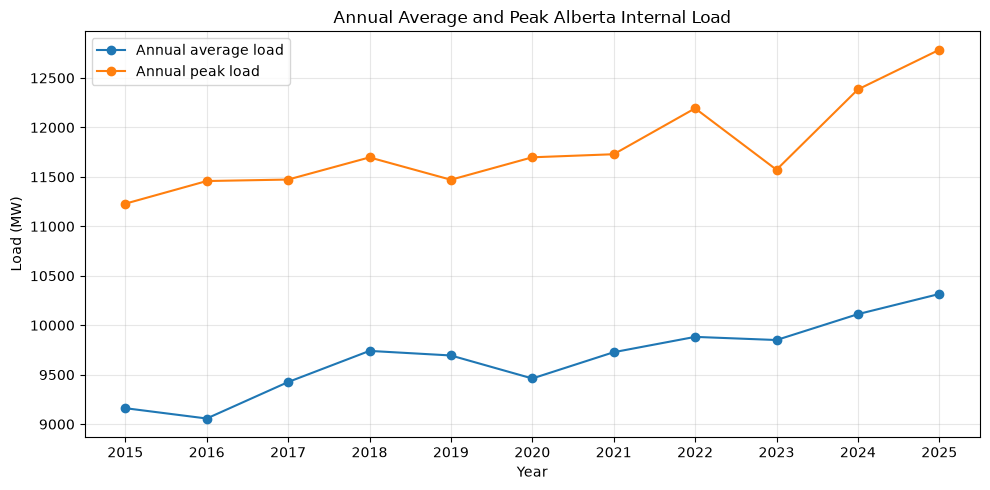

In [12]:
# ================================================================
# Monthly Demand Evolution
# ================================================================

plot_df = (
    annual_load
    .reindex(complete_years)
    .dropna(subset = ['average_load_mw', 'peak_load_mw'])
)

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(
    plot_df.index,
    plot_df['average_load_mw'],
    marker = 'o',
    label = 'Annual average load',
)

ax.plot(
    plot_df.index,
    plot_df['peak_load_mw'],
    marker = 'o',
    label = 'Annual peak load',
)

ax.set_title('Annual Average and Peak Alberta Internal Load')
ax.set_xlabel('Year')
ax.set_ylabel('Load (MW)')
ax.set_xticks(plot_df.index)
ax.legend()
ax.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

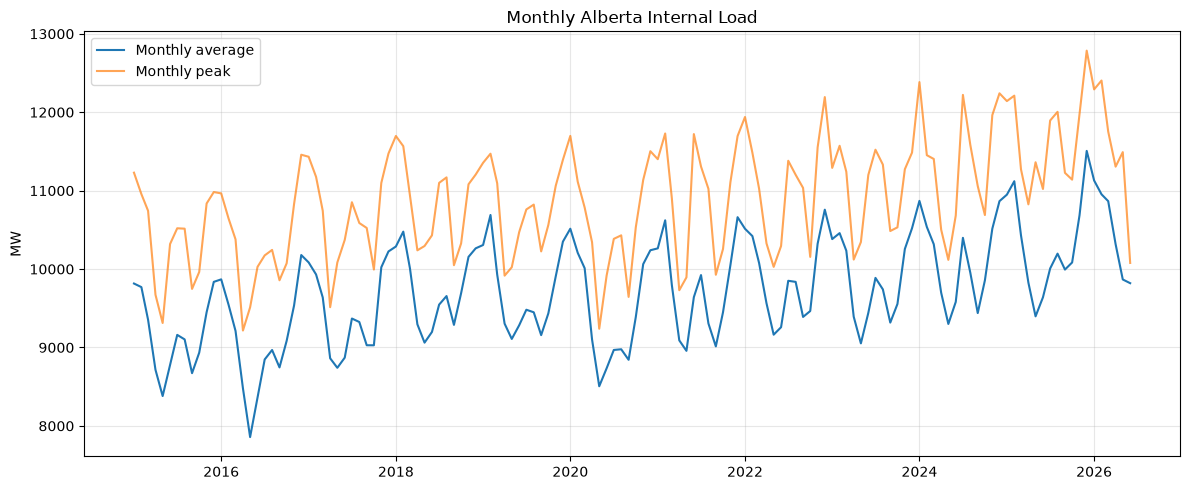

In [13]:
# ================================================================
# Average and Peak Demand Chart
# ================================================================

monthly_load = (
    market.set_index("timestamp_utc")[load_col]
    .resample("MS")
    .agg(["mean", "max"])
    .rename(columns={
        "mean": "average_load_mw",
        "max": "peak_load_mw"
    })
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_load.index,
    monthly_load["average_load_mw"],
    label="Monthly average"
)

ax.plot(
    monthly_load.index,
    monthly_load["peak_load_mw"],
    alpha=0.7,
    label="Monthly peak"
)

ax.set_title("Monthly Alberta Internal Load")
ax.set_xlabel("")
ax.set_ylabel("MW")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Alberta Internal Load shows a clear long-run upward trend, with average demand increasing from approximately 9.16 GW in 2015 to 10.32 GW in 2025. Annual energy consumption rose from 80.3 TWh to 90.4 TWh over the same period. Growth was uneven, including declines in 2016, 2019, 2020, and 2023, but demand reached new highs in 2024 and 2025. Peak demand also increased, reaching 12.79 GW in 2025, although annual peaks were considerably more volatile than annual averages because they are influenced by isolated extreme-weather events. Monthly demand displays a strongly seasonal pattern, with the highest average and peak loads typically occurring from November through February and the lowest loads occurring during the spring and early fall shoulder seasons. Summer demand has also become increasingly important, particularly in July and August 2024–2025, suggesting that cooling-related load may be contributing more materially to system peaks. Overall, the results indicate both structural load growth and persistent weather-driven seasonality, which should be explicitly represented in later forecasting and scarcity analysis.

##### 1.2 - How Has Generation Mix Changed?

In [14]:
generation_candidates = [
    column for column in generation.columns
    if "generation" in column.lower()
]

In [15]:
GENERATION_COLUMNS = {
    "Coal": "coal_system_generation",
    "Cogeneration": "cogeneration_system_generation",
    "Combined Cycle": "combined_cycle_system_generation",
    "Dual Fuel": "dual_fuel_system_generation",
    "Gas-Fired Steam": "gas_fired_steam_system_generation",
    "Hydro": "hydro_system_generation",
    "Other": "other_system_generation",
    "Simple Cycle": "simple_cycle_system_generation",
    "Solar": "solar_system_generation",
    "Storage": "storage_system_generation",
    "Wind": "wind_system_generation",
}

In [16]:
invalid_generation_columns = {
    fuel: column
    for fuel, column in GENERATION_COLUMNS.items()
    if column not in generation.columns
}

print("Invalid generation mappings:", invalid_generation_columns)

Invalid generation mappings: {}


In [17]:
generation_analysis = generation.merge(
    calendar[["timestamp_utc", "year_alberta"]],
    on="timestamp_utc",
    how="left",
    validate="one_to_one",
)

generation_analysis["year_alberta"] = pd.to_numeric(
    generation_analysis["year_alberta"],
    errors="coerce",
).astype("Int64")

annual_generation_gwh = (
    generation_analysis
    .groupby("year_alberta")[list(GENERATION_COLUMNS.values())]
    .sum(min_count=1)
    .div(1_000)
    .rename(columns={
        column: fuel
        for fuel, column in GENERATION_COLUMNS.items()
    })
)

complete_years_index = pd.Index(complete_years, dtype="int64")

annual_generation_gwh = annual_generation_gwh.loc[
    annual_generation_gwh.index.intersection(complete_years_index)
]

print("Shape:", annual_generation_gwh.shape)
print("Years:", annual_generation_gwh.index.tolist())

display(annual_generation_gwh.round(1))

Shape: (11, 11)
Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,Coal,Cogeneration,Combined Cycle,Dual Fuel,Gas-Fired Steam,Hydro,Other,Simple Cycle,Solar,Storage,Wind
2015,39392.8,10357.8,5033.8,NaN,NaN,1708.2,570.3,703.8,NaN,NaN,4089.2
2016,38424.0,10427.4,5943.7,NaN,NaN,1733.0,609.1,741.0,NaN,NaN,4405.1
2017,37138.6,10933.4,7246.4,NaN,NaN,1887.2,515.8,888.1,0.1,NaN,4486.3
2018,28523.0,14066.5,9187.4,473.9,NaN,1861.2,651.6,2486.5,22.4,NaN,4104.1
2019,27199.9,14227.0,9652.2,708.6,NaN,1995.6,623.2,2815.2,20.3,NaN,4115.8
2020,20164.0,13795.4,10085.5,2243.3,NaN,2035.3,569.7,2453.8,86.3,0.1,6079.4
2021,15404.8,14321.1,9776.1,2606.6,3616.1,1818.2,697.5,3562.1,477.0,0.6,6132.9
2022,9711.9,13907.8,10703.7,597.9,10509.6,1922.6,651.1,3542.2,1163.9,0.7,7315.3
2023,6519.6,13515.3,10884.4,4038.7,10602.5,1688.8,698.0,2436.1,2311.2,1.8,10283.9
2024,1775.6,14057.7,16219.9,1976.0,11192.0,1613.7,552.2,3977.7,2882.3,5.1,12796.8


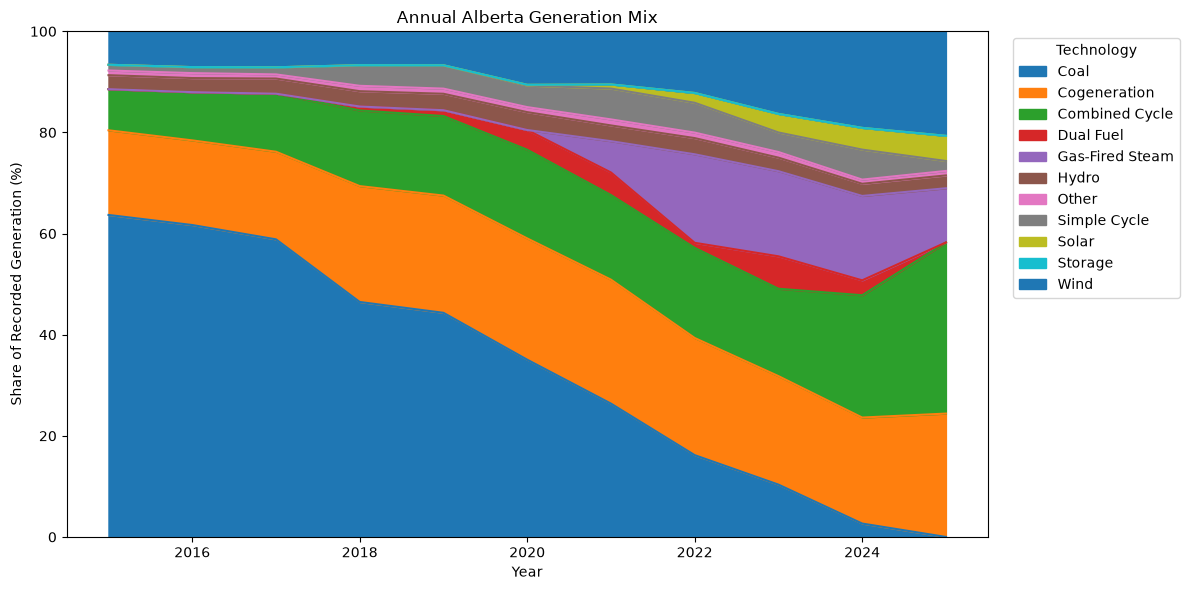

In [18]:
annual_generation_share = annual_generation_gwh.div(
    annual_generation_gwh.sum(axis=1),
    axis=0
) * 100

fig, ax = plt.subplots(figsize=(12, 6))

annual_generation_share.plot(
    kind="area",
    stacked=True,
    ax=ax
)

ax.set_title("Annual Alberta Generation Mix")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Recorded Generation (%)")
ax.set_ylim(0, 100)
ax.legend(
    title="Technology",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [19]:
annual_generation_share = (
    annual_generation_gwh.div(
        annual_generation_gwh.sum(axis=1),
        axis=0
    ) * 100
)

annual_generation_share.round(1)

,Coal,Cogeneration,Combined Cycle,Dual Fuel,Gas-Fired Steam,Hydro,Other,Simple Cycle,Solar,Storage,Wind
2015,63.7,16.7,8.1,NaN,NaN,2.8,0.9,1.1,NaN,NaN,6.6
2016,61.7,16.7,9.5,NaN,NaN,2.8,1.0,1.2,NaN,NaN,7.1
2017,58.9,17.3,11.5,NaN,NaN,3.0,0.8,1.4,0.0,NaN,7.1
2018,46.5,22.9,15.0,0.8,NaN,3.0,1.1,4.1,0.0,NaN,6.7
2019,44.3,23.2,15.7,1.2,NaN,3.3,1.0,4.6,0.0,NaN,6.7
2020,35.1,24.0,17.5,3.9,NaN,3.5,1.0,4.3,0.2,0.0,10.6
2021,26.4,24.5,16.7,4.5,6.2,3.1,1.2,6.1,0.8,0.0,10.5
2022,16.2,23.2,17.8,1.0,17.5,3.2,1.1,5.9,1.9,0.0,12.2
2023,10.4,21.5,17.3,6.4,16.8,2.7,1.1,3.9,3.7,0.0,16.3
2024,2.6,21.0,24.2,2.9,16.7,2.4,0.8,5.9,4.3,0.0,19.1


Generation mix (2015–2025)

Alberta's generation portfolio underwent a substantial structural transformation over the study period. Coal-fired generation declined from approximately 64% of annual generation in 2015 to negligible levels by mid-2024, reflecting the province's accelerated coal phase-out. Over the same period, combined-cycle natural gas expanded from approximately 8% to 24% of annual generation, while cogeneration remained relatively stable, consistently contributing between 21% and 25% of annual generation.

Renewable generation also expanded considerably. Wind generation increased from 6.6% of annual generation in 2015 to approximately 19% by 2024, while solar generation grew from effectively zero to over 4% as new utility-scale projects entered service. Gas-fired steam generation emerged as a distinct reporting category in 2021 and supplied approximately 11–18% of annual generation thereafter. Hydroelectric generation remained relatively stable at roughly 2–3% of annual generation, while energy storage contributed only a negligible share throughout the study period.

Overall, the results illustrate Alberta's transition from a coal-dominated electricity system toward a more diversified generation mix centred on natural gas and increasing renewable penetration. By the end of the study period, natural gas technologies—including combined-cycle, cogeneration, gas-fired steam, and simple-cycle generation—together accounted for the majority of recorded electricity generation, complemented by rapidly expanding wind and solar capacity.

Reporting note: Duel fuel was a naming convention for generating units that were capable of burning both coal and natural gas during the transition to natural gas. Beginning in the second half of 2024, the AESO discontinued separate reporting of the Coal and Dual Fuel generation categories following Alberta's completion of the off-coal transition. Coal generation had effectively ceased, while the remaining dual-fuel units completed conversion to natural gas technologies. Consequently, generation shares reported for 2025 are not directly comparable with earlier years because the underlying technology classifications changed.

##### 1.3 - How had installed capacity changed?

In [20]:
capacity_candidates = [
    column for column in generation.columns
    if 'maximum_capacity' in column.lower()
]

capacity_candidates

['coal_maximum_capacity',
 'cogeneration_maximum_capacity',
 'combined_cycle_maximum_capacity',
 'dual_fuel_maximum_capacity',
 'gas_fired_steam_maximum_capacity',
 'hydro_maximum_capacity',
 'other_maximum_capacity',
 'simple_cycle_maximum_capacity',
 'solar_maximum_capacity',
 'storage_maximum_capacity',
 'wind_maximum_capacity',
 'total_maximum_capacity']

In [21]:
CAPACITY_COLUMNS = {
    "Coal": "coal_maximum_capacity",
    "Cogeneration": "cogeneration_maximum_capacity",
    "Combined cycle": "combined_cycle_maximum_capacity",
    "Simple cycle": "simple_cycle_maximum_capacity",
    "Gas-fired steam": "gas_fired_steam_maximum_capacity",
    "Hydro": "hydro_maximum_capacity",
    "Other": "other_maximum_capacity",
    "Simple cycle": "simple_cycle_maximum_capacity",
    "Solar": "solar_maximum_capacity",
    "Storage": "storage_maximum_capacity",
    "Wind": "wind_maximum_capacity",
    "Total": "total_maximum_capacity",
}

In [22]:
invalid_capacity_columns = {
    fuel: column
    for fuel, column in CAPACITY_COLUMNS.items()
    if column not in master.columns
}

print("Invalid capacity mappings:", invalid_capacity_columns)

Invalid capacity mappings: {}


In [23]:
annual_capacity_mw = pd.DataFrame({
    fuel: master.groupby('year_alberta')[column].max()
    for fuel, column in CAPACITY_COLUMNS.items()
})

annual_capacity_mw.round(1)

,Coal,Cogeneration,Combined cycle,Simple cycle,Gas-fired steam,Hydro,Other,Solar,Storage,Wind,Total
year_alberta,,,,,,,,,,,
2015,6289.0,4554.0,1758.0,946.0,NaN,894.0,386.0,NaN,NaN,1463.0,16290.0
2016,6299.0,4779.0,1758.0,952.0,NaN,894.0,395.0,NaN,NaN,1463.0,16423.0
2017,6299.0,4986.0,1745.0,866.0,NaN,894.0,395.0,15.0,NaN,1445.0,16626.0
2018,6003.0,4987.0,1790.0,871.0,NaN,894.0,392.0,15.0,NaN,1445.0,16390.0
2019,5568.0,5093.0,1790.0,871.0,NaN,894.0,381.0,15.0,NaN,1781.0,16532.0
2020,5034.0,5136.0,1798.0,1076.0,NaN,894.0,381.0,107.0,30.0,1791.0,16547.0
2021,4132.0,5247.0,1798.0,1182.0,1981.0,894.0,391.0,736.0,50.0,2269.0,17224.0
2022,1729.0,5285.0,1852.0,1190.0,2712.0,894.0,402.0,1138.0,70.0,3618.0,18344.0
2023,820.0,5304.0,3052.0,1209.0,2609.0,894.0,402.0,1650.0,190.0,4491.0,20787.0


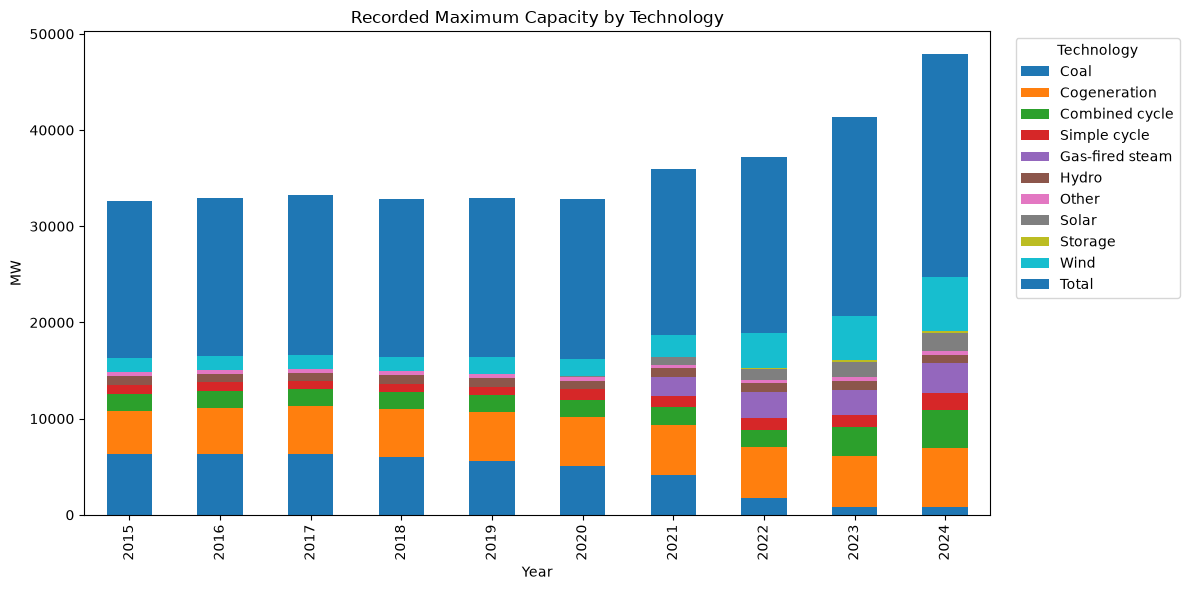

In [24]:
fig, ax = plt.subplots(figsize = (12, 6))

annual_capacity_mw.plot(
    kind = 'bar',
    stacked = True,
    ax = ax
)

ax.set_title('Recorded Maximum Capacity by Technology')
ax.set_xlabel('Year')
ax.set_ylabel('MW')
ax.legend(
    title = 'Technology',
    bbox_to_anchor = (1.02, 1),
    loc = 'upper left'
)

plt.tight_layout()
plt.show()

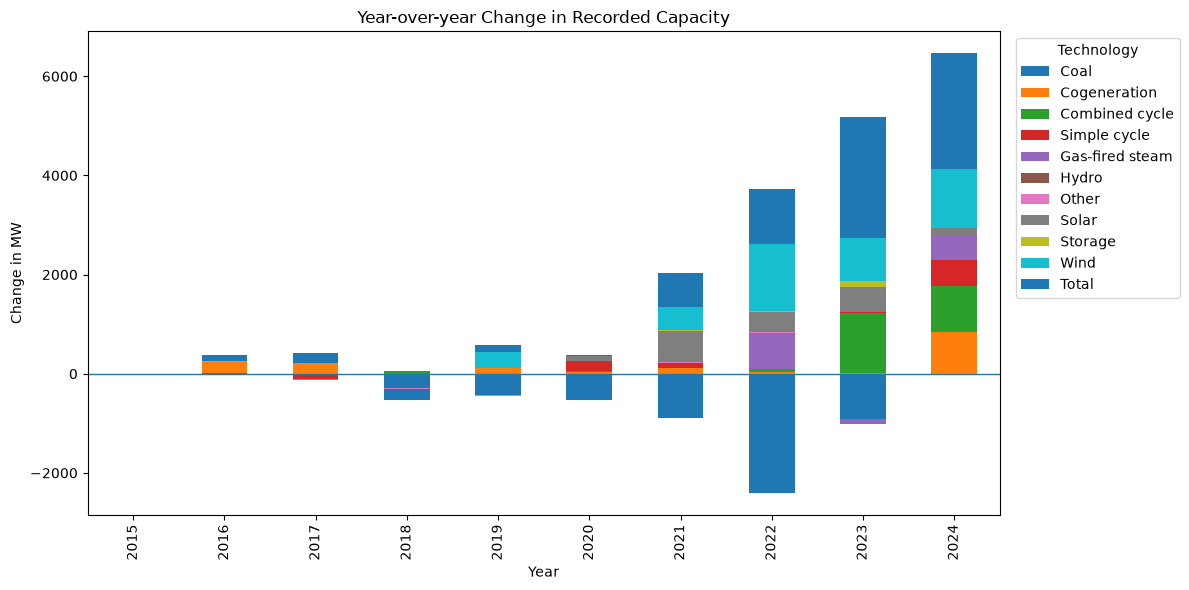

In [25]:
capacity_change_mw = annual_capacity_mw.diff()

fig, ax = plt.subplots(figsize = (12, 6))

capacity_change_mw.plot(
    kind = 'bar',
    stacked = True,
    ax = ax
)

ax.axhline(0, linewidth = 1)
ax.set_title('Year-over-year Change in Recorded Capacity')
ax.set_xlabel('Year')
ax.set_ylabel('Change in MW')
ax.legend(
    title = "Technology",
    bbox_to_anchor = (1.01, 1),
    loc = 'upper left'
)

plt.tight_layout()
plt.show()

Installed capacity (2015-2025):

Alberta's installed generation capacity increased substantially over the study period, rising from approximately 16.3 GW in 2015 to 23.1 GW in 2024. This expansion occurred alongside a fundamental shift in the province's generation fleet, driven by the retirement of coal-fired generation, growth in natural gas technologies, and rapid renewable development.

Coal capacity declined from approximately 6.3 GW in 2015 to 0.8 GW by 2023 as Alberta completed its transition away from coal-fired electricity generation. Over the same period, combined-cycle capacity more than doubled from 1.8 GW to 4.0 GW, while simple-cycle capacity increased from 0.9 GW to 1.7 GW. Cogeneration capacity also expanded steadily, increasing from 4.6 GW to 6.1 GW. Wind capacity nearly quadrupled from 1.5 GW to 5.7 GW, while utility-scale solar grew from virtually no installed capacity to approximately 1.8 GW. Hydroelectric capacity remained largely unchanged throughout the study period, and grid-scale battery storage first appeared in 2020 before expanding modestly to 190 MW by 2024.

Overall, the results demonstrate that Alberta's electricity system not only replaced retiring coal capacity but also expanded total installed capacity through significant investment in natural gas and renewable generation technologies.

Reporting note: Gas-fired steam capacity first appears as a distinct AESO reporting category in 2021 and should not be interpreted as entirely new capacity entering the system. Similarly, the Coal and Dual Fuel categories reflect Alberta's coal-to-gas transition and subsequent changes in AESO technology classifications. As a result, changes in these categories represent both physical changes to the generation fleet and evolving reporting practices.

##### 1.4 - How has intertie usage changed?

In [26]:
print([column for column in master.columns if 'import' in column.lower()])
print([column for column in master.columns if 'export' in column.lower()])

['import_bc', 'import_mt', 'import_sk', 'import_bc_raw', 'import_mt_raw', 'import_sk_raw', 'total_imports_mw', 'net_imports_mw', 'is_net_importing', 'total_imports_mw_lag_1h', 'total_imports_mw_lag_3h', 'total_imports_mw_lag_6h', 'total_imports_mw_lag_12h', 'total_imports_mw_lag_24h', 'total_imports_mw_change_1h', 'total_imports_mw_change_3h', 'total_imports_mw_change_6h', 'total_imports_mw_change_24h', 'net_imports_mw_lag_1h', 'net_imports_mw_lag_3h', 'net_imports_mw_lag_6h', 'net_imports_mw_lag_12h', 'net_imports_mw_lag_24h', 'net_imports_mw_change_1h', 'net_imports_mw_change_3h', 'net_imports_mw_change_6h', 'net_imports_mw_change_24h', 'import_adjusted_load_mw', 'imports_as_share_of_ail', 'atc_sk_import', 'atc_wecc_import', 'ttc_sk_import', 'ttc_wecc_import']
['export_bc', 'export_mt', 'export_sk', 'export_bc_raw', 'export_mt_raw', 'export_sk_raw', 'total_exports_mw', 'is_net_exporting', 'total_exports_mw_lag_1h', 'total_exports_mw_lag_3h', 'total_exports_mw_lag_6h', 'total_exports_

In [27]:
imports_col = "total_imports_mw"
exports_col = "total_exports_mw"
net_imports_col = "net_imports_mw"

In [28]:
annual_interties = (
    master.groupby('year_alberta').agg(
        average_total_imports_mw = (imports_col, 'mean'),
        peak_total_import_mw = (imports_col, 'max'),
        total_import_energy_gwh = (imports_col, lambda series: series.sum(min_count = 1) / 1_000),
        average_total_exports_mw = (exports_col, 'max'),
        total_export_energy_gwh = (exports_col, lambda series: series.sum(min_count = 1) / 1_000),
        average_net_imports_mw = (net_imports_col, 'mean'),
        peak_net_imports_mw = (net_imports_col, 'max'),
        minimum_net_imports_mw = (net_imports_col, 'min'),
        net_importing_hours = ('is_net_importing', 'sum'),
        net_exporting_hours = ('is_net_exporting', 'sum'),
    )
)

annual_interties['net_import_energy_gwh'] = (
    annual_interties['total_import_energy_gwh'] - annual_interties['total_export_energy_gwh']
)

annual_interties.round(2)

,average_total_imports_mw,peak_total_import_mw,total_import_energy_gwh,average_total_exports_mw,total_export_energy_gwh,average_net_imports_mw,peak_net_imports_mw,minimum_net_imports_mw,net_importing_hours,net_exporting_hours,net_import_energy_gwh
year_alberta,,,,,,,,,,,
2015,124.57,1002.0,1091.22,877.0,650.55,50.30,1002.0,-877.0,4151,2982,440.67
2016,49.52,769.0,435.02,935.0,866.74,-49.15,729.0,-935.0,2408,3749,-431.72
2017,147.79,998.0,1294.66,935.0,1021.61,31.17,998.0,-935.0,3104,4363,273.05
2018,387.42,1092.0,3393.79,1010.0,730.60,304.02,1092.0,-1010.0,6390,1890,2663.19
2019,243.43,1154.0,2132.42,1075.0,610.13,173.78,1154.0,-939.0,6368,1765,1522.29
2020,451.45,1118.0,3965.51,593.0,97.80,440.31,1118.0,-332.0,8387,75,3867.71
2021,473.81,1059.0,4150.55,685.0,131.46,458.80,1022.0,-532.0,8550,150,4019.09
2022,484.41,983.0,4243.42,1085.0,630.31,412.46,983.0,-939.0,7810,942,3613.11
2023,248.57,888.0,2177.47,1100.0,2169.12,0.95,888.0,-1026.0,5243,3466,8.35


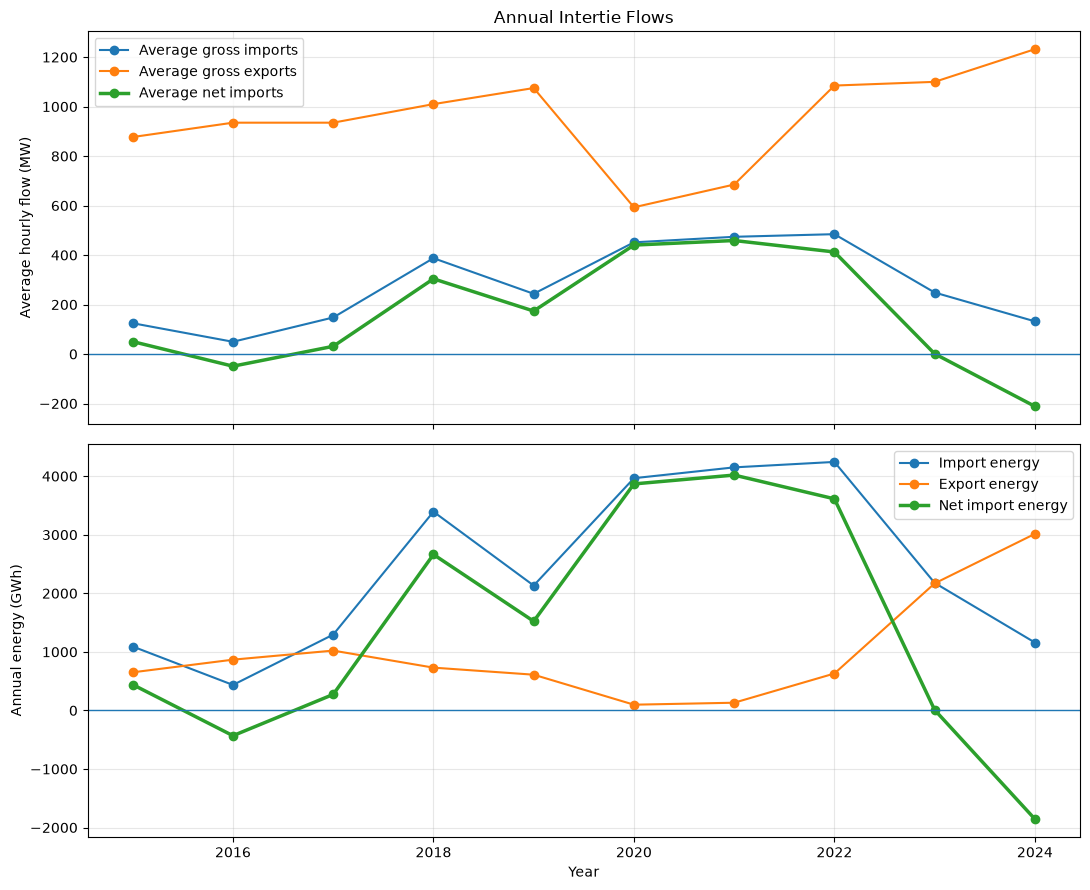

In [29]:
available_complete_years = annual_interties.index.intersection(complete_years)

plot_df = annual_interties.loc[available_complete_years]

fig, axes = plt.subplots(
    nrows = 2, 
    ncols = 1, 
    figsize = (11, 9), 
    sharex = True,
)

# -------------------------------------------------------------------------
# Panel 1: Average hourly flows
# -------------------------------------------------------------------------

axes[0].plot(
    plot_df.index,
    plot_df['average_total_imports_mw'],
    marker = 'o',
    label = 'Average gross imports',
)

axes[0].plot(
    plot_df.index,
    plot_df['average_total_exports_mw'],
    marker = 'o',
    label = 'Average gross exports',
)

axes[0].plot(
    plot_df.index,
    plot_df['average_net_imports_mw'],
    marker = 'o',
    linewidth = 2.5, 
    label = 'Average net imports',
)

axes[0].axhline(
    0, 
    linewidth = 1,
)

axes[0].set_title(
    'Annual Intertie Flows'
)

axes[0].set_ylabel(
    'Average hourly flow (MW)'
)

axes[0].legend()
axes[0].grid(alpha = 0.3)

# -------------------------------------------------------------------------
# Panel 2: Annual energy flows
# -------------------------------------------------------------------------

axes[1].plot(
    plot_df.index,
    plot_df['total_import_energy_gwh'],
    marker = 'o',
    label = 'Import energy',
)

axes[1].plot(
    plot_df.index,
    plot_df['total_export_energy_gwh'],
    marker = 'o',
    label = 'Export energy',
)

axes[1].plot(
    plot_df.index,
    plot_df['net_import_energy_gwh'],
    marker = 'o',
    linewidth = 2.5, 
    label = 'Net import energy',
)

axes[1].axhline(
    0, 
    linewidth = 1,
)

axes[1].set_xlabel(
    'Year'
)

axes[1].set_ylabel(
    'Annual energy (GWh)'
)

axes[1].legend()
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()


In [31]:
master['imports_share_of_load'] = (
    master[imports_col] / master[load_col]
)

annual_import_share = (
    master.groupby('year_alberta')['imports_share_of_load']
    .agg(['mean', 'median', 'max'])
    .rename(columns={
        'mean': 'average_share',
        'median': 'median_share',
        'max': 'maximum_share',
    }) * 100
)

annual_import_share.round(2)

,average_share,median_share,maximum_share
year_alberta,,,
2015,1.30,0.47,9.99
2016,0.55,0.00,7.21
2017,1.66,0.00,12.17
2018,4.03,3.16,13.05
2019,2.53,1.66,12.81
2020,4.82,4.17,14.27
2021,4.82,4.70,10.86
2022,4.90,5.06,10.94
2023,2.54,2.16,7.78


Intertie flows (2015–2024):

Alberta's intertie flows changed substantially over the study period. Between 2015 and 2017, the province alternated between modest net importing and net exporting positions, with annual net energy flows remaining relatively balanced. Import dependence then increased sharply beginning in 2018. Net import energy rose to approximately 2.7 TWh in 2018 and peaked at roughly 4.0 TWh in 2021, when Alberta was a net importer during 8,550 hours and recorded average net imports of approximately 459 MW.

This pattern reversed after 2021. Net import energy declined in 2022, while gross exports increased substantially during 2023 and 2024. Imports and exports were almost exactly balanced in 2023, resulting in only 8 GWh of net import energy. By 2024, Alberta had become a substantial net exporter, recording approximately 1.9 TWh of net export energy and average net exports of roughly 211 MW. The province was a net exporter during 5,665 hours that year.

Overall, the results indicate that Alberta's interties shifted from serving primarily as a source of imported supply during 2018–2022 to increasingly facilitating electricity exports by the end of the study period. This transition coincides with significant expansion of Alberta's generation fleet, including growth in natural gas, wind, and solar capacity, which likely increased the province's ability to export surplus generation during favourable market conditions.

Peak hourly flows remained large in both directions throughout the study period. Consequently, annual average and net energy measures should be interpreted alongside peak flows, as Alberta continued to rely on imports during individual scarcity events even in years when it was a net exporter overall.


##### 1.5 - Section 1 Summary Table

In [33]:
section_1_summary = pd.DataFrame({
    'metric': [
        'Average load, first complete year',
        'Average load, final complete year',
        'Peak load, first complete year',
        'Peak load, final complete year',
        'Average imports, first complete year',
        'Average imports, final complete year',
    ],
    'value': [
        annual_load.loc[complete_years[0], 'average_load_mw'],
        annual_load.loc[complete_years[-2], 'average_load_mw'],
        annual_load.loc[complete_years[0], 'peak_load_mw'],
        annual_load.loc[complete_years[-2], 'peak_load_mw'],
        annual_interties.loc[complete_years[0], 'average_total_imports_mw'],
        annual_interties.loc[complete_years[-2], 'average_total_imports_mw'],
    ]
})

section_1_summary

,metric,value
0,"Average load, first complete year",9161.746804
1,"Average load, final complete year",10112.334244
2,"Peak load, first complete year",11229.000000
3,"Peak load, final complete year",12384.000000
4,"Average imports, first complete year",124.568493
5,"Average imports, final complete year",132.085337


Alberta's average system load increased from approximately 9.2 GW in 2015 to 10.1 GW in 2024, while peak demand rose by more than 1.1 GW over the same period. Despite this increase in electricity demand, average imports remained relatively unchanged, increasing by only 7 MW. Combined with the observed transition toward net exports after 2022, these results suggest that growth in Alberta's generation fleet generally outpaced growth in electricity demand, reducing the province's dependence on imported electricity and increasing its ability to export surplus generation under favorable market conditions.

#### Section 2 - What Does a Typical Operating Day Look Like?

Electricity-market conditions follow recurring intraday, weekly, and seasonal rhythms. Demand, solar generation, wind output, imports, and prices do not behave independently of time.  
This section develops a baseline picture of normal system operation using average hourly profiles. These averages are not intended to describe every day; rather, they identify recurring operating patterns against which unusual conditions can later be compared.

##### 2.1 - Typical hourly demand profile

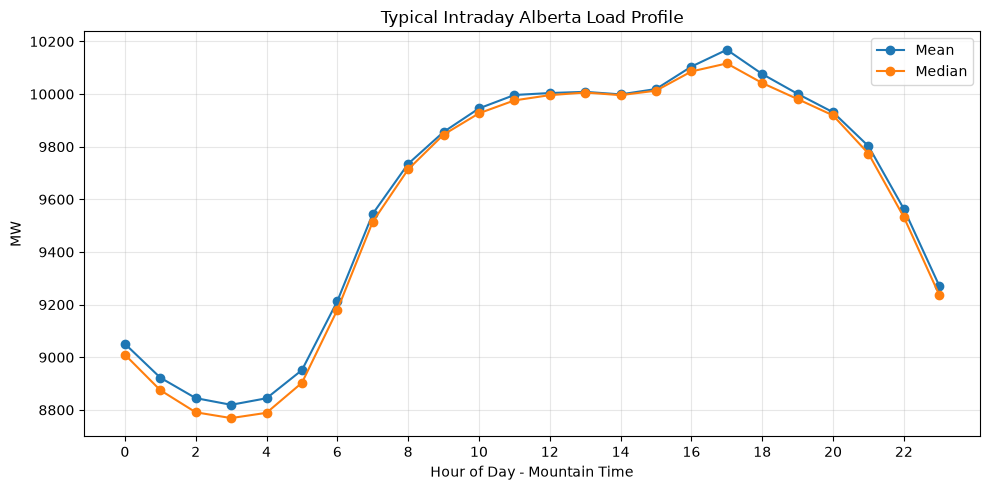

In [35]:
hourly_load_profile = (
    master.groupby('hour_alberta')[load_col]
    .agg(['mean', 'median'])
)

fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile['mean'],
    marker = 'o',
    label = 'Mean'
)

ax.plot(
    hourly_load_profile.index,
    hourly_load_profile['median'],
    marker = 'o',
    label = 'Median'
)

ax.set_title('Typical Intraday Alberta Load Profile')
ax.set_xlabel('Hour of Day - Mountain Time')
ax.set_ylabel('MW')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

##### 2.2 - Weeday versus weekend demand

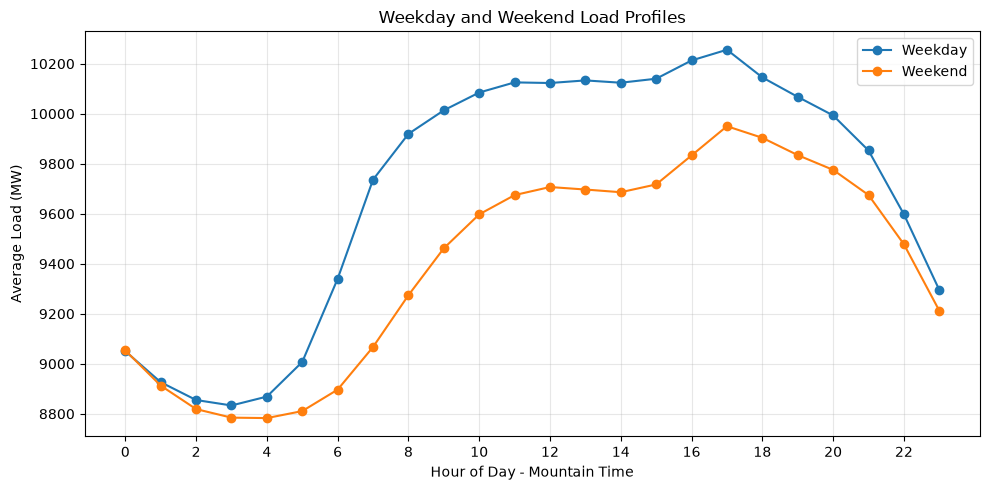

In [37]:
weekday_profile = (
    master.groupby(['hour_alberta', 'is_weekend'])[load_col]
    .mean()
    .unstack()
    .rename(columns = {
        False: 'Weekday', 
        True: 'Weekend',
    })
)

fig, ax = plt.subplots(figsize = (10, 5))

for column in weekday_profile.columns: 
    ax.plot(
        weekday_profile.index,
        weekday_profile[column],
        marker = 'o',
        label = column
    )

ax.set_title('Weekday and Weekend Load Profiles')
ax.set_xlabel('Hour of Day - Mountain Time')
ax.set_ylabel("Average Load (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

##### 2.3 - Seasonal demand profiles

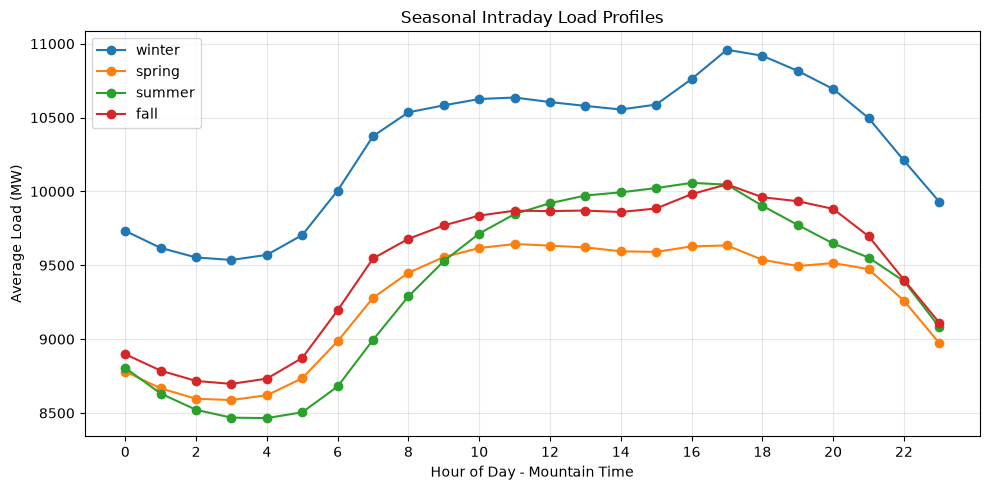

In [46]:
season_order = ['winter', 'spring', 'summer', 'fall']

seasonal_load_profile = (
    master.groupby(['hour_alberta', 'season'])[load_col]
    .mean()
    .unstack()
    .reindex(columns = season_order)
)

fig, ax = plt.subplots(figsize = (10, 5))

for season in seasonal_load_profile.columns:
    ax.plot(
        seasonal_load_profile.index,
        seasonal_load_profile[season],
        marker = 'o',
        label = season
    )

ax.set_title('Seasonal Intraday Load Profiles')
ax.set_xlabel('Hour of Day - Mountain Time')
ax.set_ylabel('Average Load (MW)')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

##### 2.4 - Typical wind, price, and import profiles

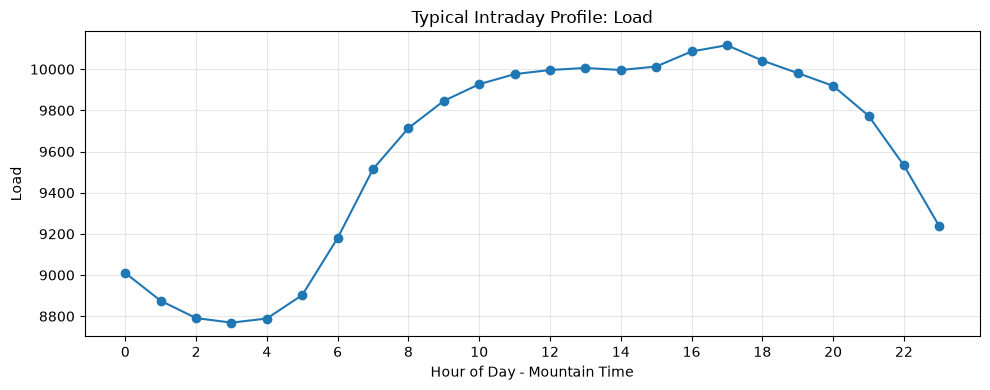

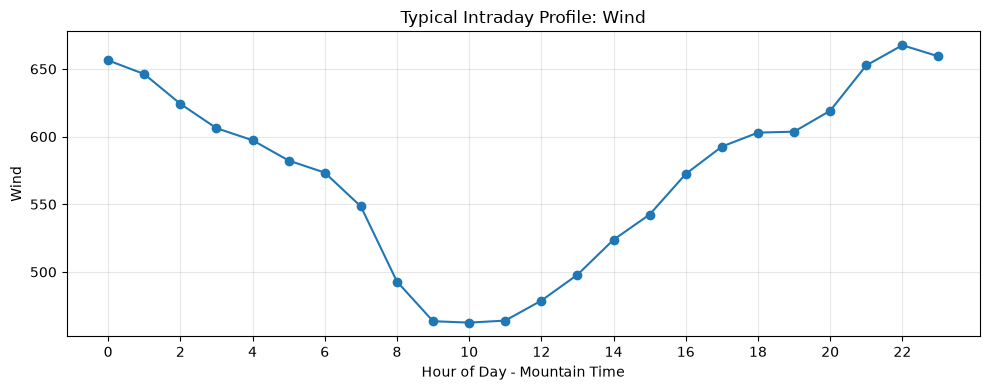

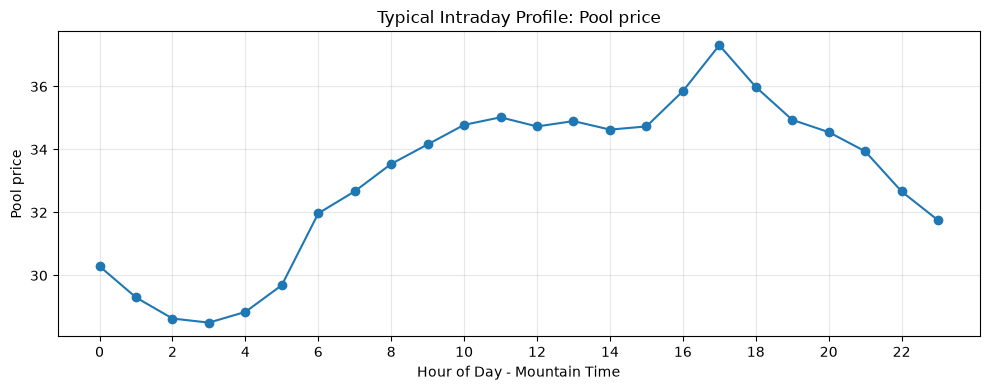

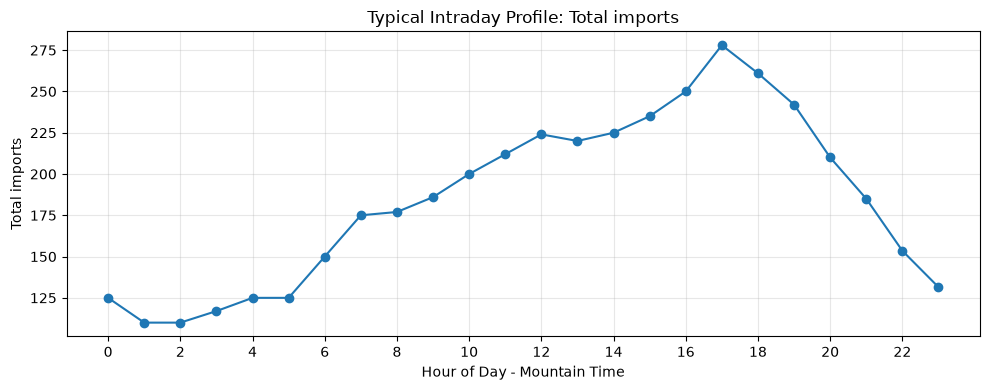

In [52]:
profile_variables = {
    'Load': 'ail_mw', 
    'Wind': 'wind_system_generation', 
    'Pool price': 'pool_price',
    'Total imports': 'total_imports_mw',
}

for label, column in profile_variables.items():
    profile = master.groupby('hour_alberta')[column].median()

    fig, ax = plt.subplots(figsize = (10, 4))

    ax.plot(profile.index, profile.values, marker = 'o')
    ax.set_title(f'Typical Intraday Profile: {label}')
    ax.set_xlabel('Hour of Day - Mountain Time')
    ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(alpha = 0.3)

    plt.tight_layout()
    plt.show()


##### 2.5 - Seasonal solar and wind profiles

In [59]:
solar_candidates = [
    column for column in master.columns
    if 'solar' in column.lower()
]

solar_candidates

['solar_outage',
 'solar_system_generation',
 'solar_total_generation',
 'solar_system_available',
 'solar_system_capacity',
 'solar_maximum_capacity',
 'load_weighted_surface_solar_radiation_downwards',
 'load_weighted_solar_radiation_wm2',
 'solar_installed_capacity_mw',
 'solar_active_project_count',
 'solar_active_weather_site_count',
 'solar_capacity_weighted_surface_solar_radiation_downwards',
 'solar_capacity_weighted_surface_solar_radiation_downwards_clear_sky',
 'solar_capacity_weighted_total_sky_direct_solar_radiation',
 'solar_capacity_weighted_temperature_2m',
 'solar_capacity_weighted_skin_temperature',
 'solar_capacity_weighted_total_cloud_cover',
 'solar_capacity_weighted_high_cloud_cover',
 'solar_capacity_weighted_medium_cloud_cover',
 'solar_capacity_weighted_low_cloud_cover',
 'solar_capacity_weighted_total_precipitation',
 'solar_capacity_weighted_snowfall',
 'solar_capacity_weighted_snow_depth',
 'solar_capacity_weighted_radiation_wm2',
 'solar_clear_sky_radiation_

In [60]:
solar_col = 'solar_system_generation'

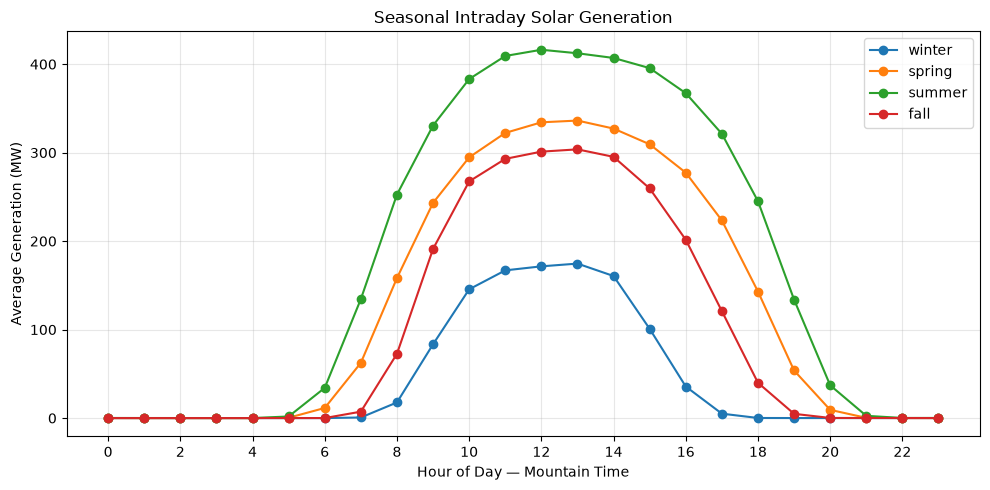

In [61]:
for label, column in {
    'Wind': 'wind_system_generation',
    'Solar': solar_col,
}.items():
    
    seasonal_profile = (
        master.groupby(['hour_alberta', 'season'])[column]
        .mean()
        .unstack()
        .reindex(columns = season_order)
    )

fig, ax = plt.subplots(figsize = (10, 5))

for season in seasonal_profile.columns:
    ax.plot(
        seasonal_profile.index,
        seasonal_profile[season],
        marker = 'o',
        label = season
    )

ax.set_title(f"Seasonal Intraday {label} Generation")
ax.set_xlabel("Hour of Day — Mountain Time")
ax.set_ylabel("Average Generation (MW)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Section 3 - How Variable is the Market? 

Average operating profiles conceal much of the market’s risk. Electricity prices, renewable generation, outages, and system demand can exhibit asymmetric distributions, persistent periods of stress, and infrequent but operationally important extremes.  
This section examines the distributions and tails of major market variables before later notebooks investigate their drivers.

##### 3.1 - Distribution summary

In [65]:
distribution_columns = {
    "Load": "ail_mw",
    "Pool price": "pool_price",
    "AECO gas": "gas_price",
    "Spark spread": "spark_spread",
    "Net imports": "net_imports_mw",
    "Total imports": "total_imports_mw",
    "Total exports": "total_exports_mw",
    "Total outages": "total_outage_mw",
}

distribution_summary = pd.DataFrame({
    label: market[column].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    for label, column in distribution_columns.items()
}).T

distribution_summary.columns = [
    'p01', 'p05', 'p25', 'median', 'p75', 'p95', 'p99'
]

distribution_summary.round(3)

,p01,p05,p25,median,p75,p95,p99
Load,7776.000,8243.00,9102.00,9707.000,10345.00,11139.300,11707.460
Pool price,0.000,11.11,20.28,32.560,52.36,237.629,775.825
AECO gas,-0.022,0.46,1.61,2.250,2.73,5.125,7.000
Spark spread,-12.825,-4.50,5.42,17.615,32.57,213.353,753.143
Net imports,-935.000,-675.00,-79.00,100.000,429.00,825.000,949.000
Total imports,0.000,0.00,25.00,161.000,444.00,837.000,950.000
Total exports,0.000,0.00,0.00,0.000,147.00,746.000,974.000
Total outages,2161.300,2406.40,3007.40,3484.300,4019.30,5044.400,5751.080


Distribution Summary: 

Load remains relatively stable compared with prices. The middle 50% of demand lines between 9.10 GW and 10.35 GW, while even the 99th percentile is only 11.71 GW, indicating Alberta demand varies within a fairly narrow range over the study period. 

Pool price is highly right-skewed. The median price is only $32.56/MWh,, but the 95th percentile reaches $237.63/MWh and the 99th percentile rises to $775.83/MWh, illustrating the presence of infrequent but extreme scarcity pricing events. 

AECO gas prices are comparatively stable, with most observations between $1.61/GJ and $2.73/GJ. The negative 1st percentile reflects periods of briefly negative natural gas prices, which have occured in the Alberta market. 

Spark spreads inherit the skewness of pool prices. While the median spark spread is $17.62MWh, the upperr tail exceeds $750/MWh, indicating that generator margins expand dramatically during high-price events. 

Net imports span both positive and negative values (approximately -935 MW to +949 MW at the 1st and 99th percentiles), confirming that Alberta alternates between being a net importer and net exporter depending on system conditions. 

Total imports are often modest - the 25th percentile is only 25 MW - but occassionally approach 950 MW, indicating heavy reliance on neighbouring durisdictions during some hours. Total exports are zero for at least half of all observations (media = 0 MW), suggesting exports occur intermittently rather than continuously. However, export capability is substabtial during favourable market conditions, reaching nearly 1 GW.

Total Outages are consistently significant, with a media of 3.48 GW and a 95th percentile exceeding 5 GW, reflecting the continual presence of planned maintenance and forced outages acorss Alberta's generation fleet. 

##### 3.2 - Histograms

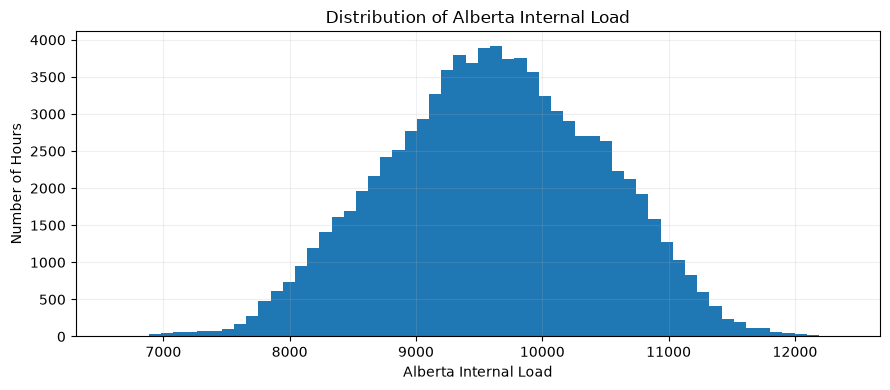

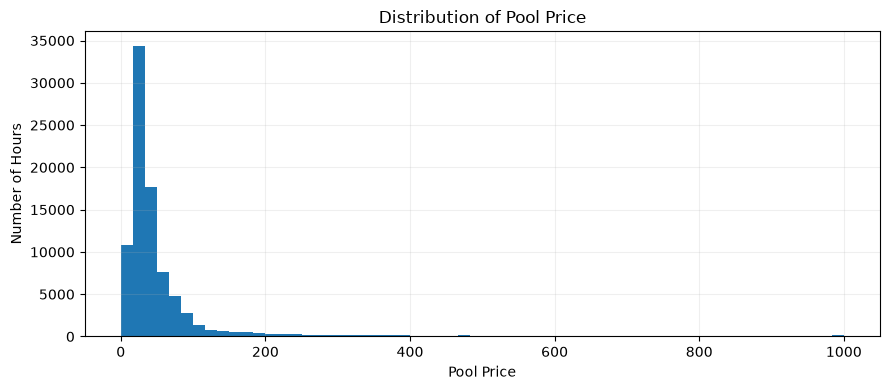

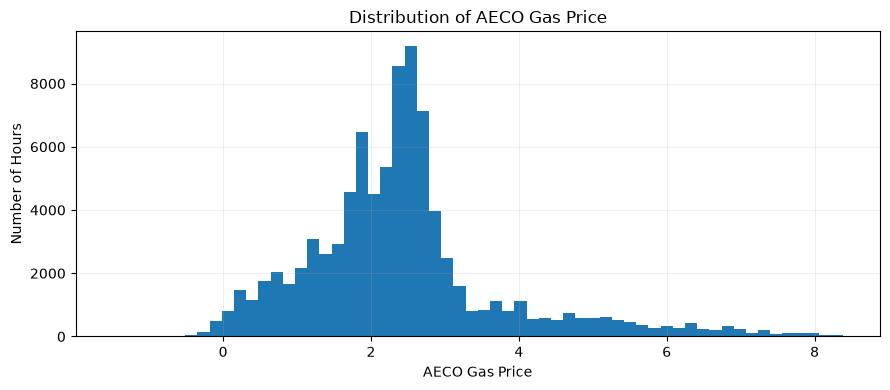

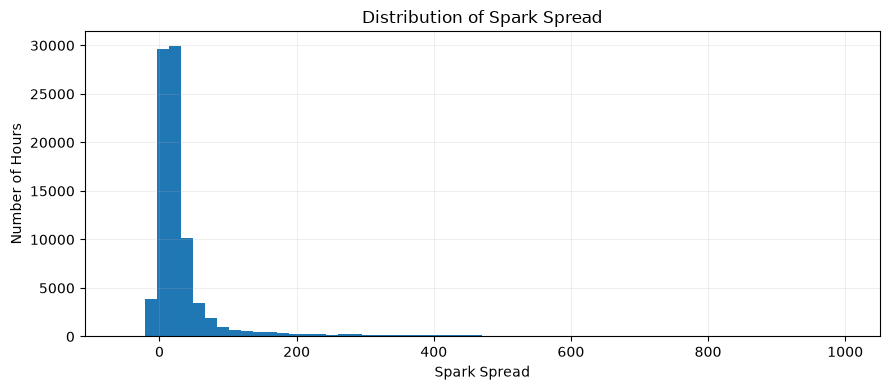

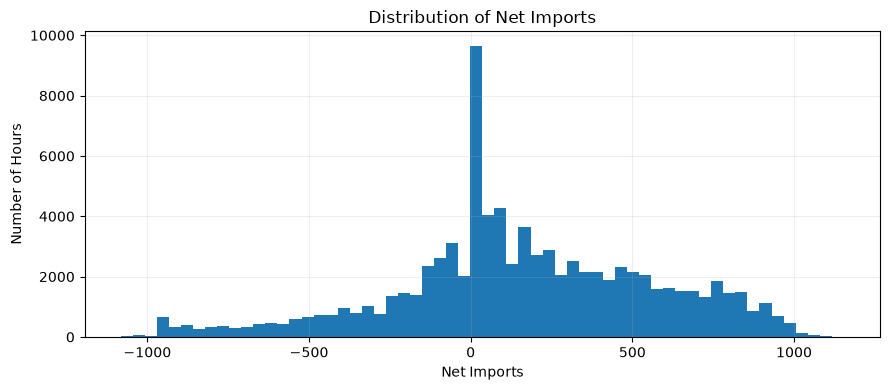

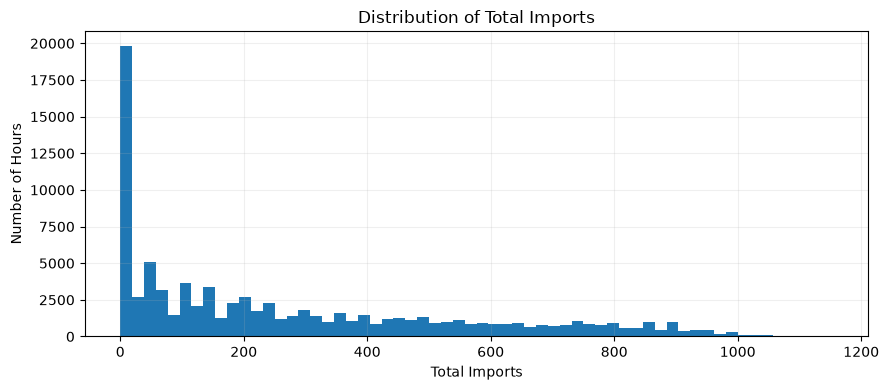

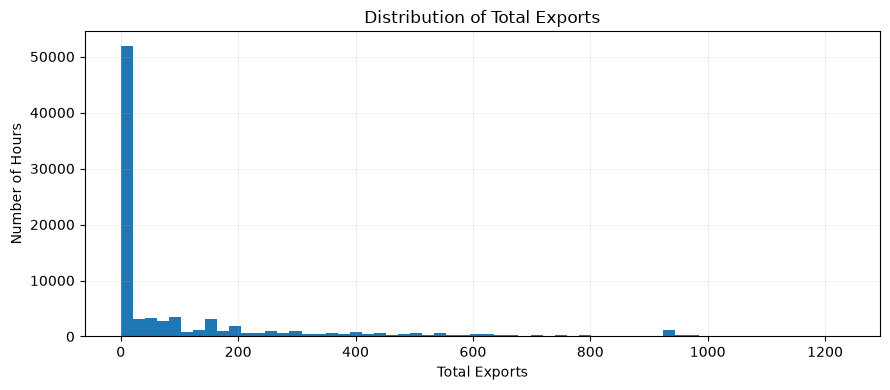

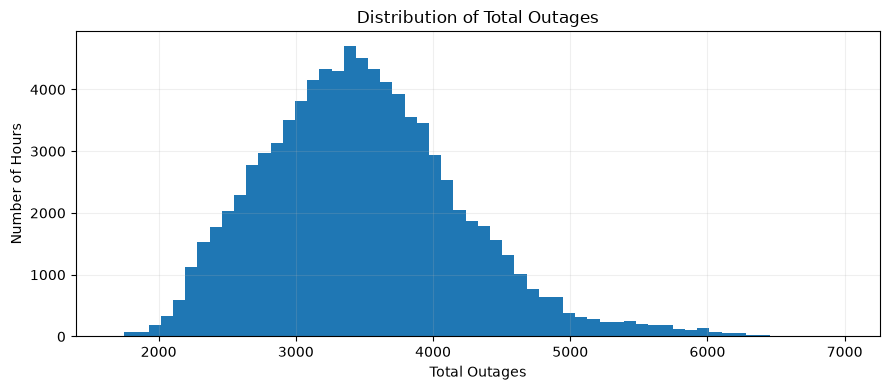

In [66]:
histogram_variables = {
    "Alberta Internal Load": "ail_mw",
    "Pool Price": "pool_price",
    "AECO Gas Price": "gas_price",
    "Spark Spread": "spark_spread",
    "Net Imports": "net_imports_mw",
    "Total Imports": "total_imports_mw",
    "Total Exports": "total_exports_mw",
    "Total Outages": "total_outage_mw",
}

for title, column in histogram_variables.items():
    values = master[column].dropna()

    fig, ax = plt.subplots(figsize = (9, 4))

    ax.hist(values, bins = 60)
    ax.set_title(f'Distribution of {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Number of Hours')
    ax.grid(alpha = 0.2)

    plt.tight_layout()
    plt.show()

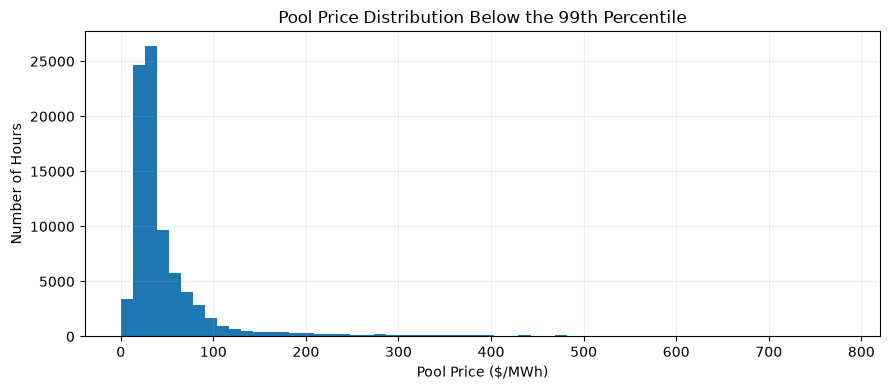

In [67]:
price_p99 = master['pool_price'].quantile(0.99)

fig, ax = plt.subplots(figsize = (9, 4))

ax.hist(master.loc[master['pool_price'] <= price_p99, 'pool_price'].dropna(),
    bins = 60
)

ax.set_title("Pool Price Distribution Below the 99th Percentile")
ax.set_xlabel("Pool Price ($/MWh)")
ax.set_ylabel("Number of Hours")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

##### 3.3 - Price exceedance frequency

In [68]:
price_thresholds = [0, 100, 200, 500, 900]

price_exceedance = pd.DataFrame({
    'threshold': price_thresholds, 
    'hours_at_or_above': [
        (market['pool_price'] >= threshold).sum()
        for threshold in price_thresholds
    ],
    'share_of_hours_pct': [
        (market['pool_price'] >= threshold).mean() * 100
        for threshold in price_thresholds
    ],
})

price_exceedance

,threshold,hours_at_or_above,share_of_hours_pct
0,0,100055,100.000000
1,100,10194,10.188396
2,200,5744,5.740843
3,500,2471,2.469642
4,900,438,0.437759


In [69]:
price_col = 'pool_price'

annual_price_extremes = (
    market.assign(
        above_100 = master[price_col] >=100, 
        above_200 = master[price_col] >= 200,
        above_500 = master[price_col] >= 500,
        at_or_above_900 = master[price_col] >= 900,
        negative_price = master[price_col] < 0,
    )
    .groupby('year_alberta')
    .agg(
        average_price=(price_col, "mean"),
        median_price=(price_col, "median"),
        price_volatility=(price_col, "std"),
        hours_above_100=("above_100", "sum"),
        hours_above_200=("above_200", "sum"),
        hours_above_500=("above_500", "sum"),
        hours_at_or_above_900=("at_or_above_900", "sum"),
        negative_price_hours=("negative_price", "sum"),     
    )
)

annual_price_extremes.round(2)

,average_price,median_price,price_volatility,hours_above_100,hours_above_200,hours_above_500,hours_at_or_above_900,negative_price_hours
year_alberta,,,,,,,,
2015,33.34,20.48,86.51,196,144,95,28,0
2016,18.28,15.46,12.63,8,4,2,0,0
2017,22.19,19.46,26.96,26,17,6,4,0
2018,50.35,33.25,87.22,361,208,102,29,0
2019,54.88,33.51,90.39,442,264,116,17,0
2020,46.72,33.28,92.13,306,189,102,40,0
2021,101.93,57.34,138.96,1651,871,310,42,0
2022,162.46,83.78,199.22,3179,1663,758,111,0
2023,133.63,57.20,183.84,2446,1547,606,52,0
